# Robustness checks

The headline number from notebook 02 is +7.7 pp on D30, controlled OLS / IPW / PSM-stratified all agreeing. Before relying on that number, I want to see how much it moves under three kinds of variation.

1. Treatment definition. What if I use got-any-answer instead of got-answer-within-24h, or got-answer-within-1h? The naive lift from the EDA was very different across these (+13.6 / +8.0 / +4.9 pp), so the controlled estimates might also differ.
2. Specification. What if I add cohort-month fixed effects (57 dummies instead of 5 year dummies) to soak up secular time trends more aggressively? What if I drop hour-of-day from the covariates? What if I keep only the question-quality features and drop timing entirely?
3. Subsample. Does the effect look different in the 2018-2019 cohorts vs the 2020+ cohorts? Pandemic and Copilot effects could shift the story.

If the +7.7 pp estimate is roughly stable across these, the project's main causal claim is on solid ground. If it moves around a lot, the claim needs more hedging.

In [1]:
import warnings

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS

import db_dtypes  # noqa: F401

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

DATA_DIR = '../data/processed'

df = pq.read_table(f'{DATA_DIR}/master.parquet').to_pandas()
df['log_body_length'] = np.log(df['body_length'].clip(lower=1))
df['cohort_year'] = pd.to_datetime(df['cohort_month']).dt.year
df['cohort_month_str'] = pd.to_datetime(df['cohort_month']).dt.strftime('%Y-%m')

for col in ['active_d30', 'active_d180', 'got_answer_within_24h', 'got_answer_within_1h',
             'got_any_answer', 'has_code_block', 'has_link', 'has_image', 'is_weekend',
             'title_length', 'num_tags', 'hour_of_day_utc', 'day_of_week', 'd180_observable']:
    df[col] = df[col].astype(float)

print(f'Loaded master.parquet: {len(df):,} rows')
print(f'D180-observable subset: {int(df["d180_observable"].sum()):,} rows')

Loaded master.parquet: 1,772,119 rows
D180-observable subset: 1,531,825 rows


## 1. Swap the treatment definition

Same outcome (D30), same covariates, just change which binary I'm calling treatment. Tells me whether the +7.7 pp estimate is specific to the 24h window or whether the answer effect is roughly the same regardless of how I bin time-to-answer.

In [2]:
covariates_full = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(hour_of_day_utc) + C(cohort_year)'
)

def quick_ols(df, outcome, treatment, covariates):
    model = smf.ols(f'{outcome} ~ {treatment} + {covariates}', data=df).fit(cov_type='HC3')
    coef = model.params[treatment]
    se = model.bse[treatment]
    ci = model.conf_int().loc[treatment]
    return coef * 100, se * 100, ci.iloc[0] * 100, ci.iloc[1] * 100

rows = []
for treat in ['got_any_answer', 'got_answer_within_24h', 'got_answer_within_1h']:
    naive = (df.loc[df[treat]==1, 'active_d30'].mean() -
             df.loc[df[treat]==0, 'active_d30'].mean()) * 100
    est, se, lo, hi = quick_ols(df, 'active_d30', treat, covariates_full)
    rows.append({'treatment': treat, 'naive_pp': naive, 'controlled_pp': est,
                 'se_pp': se, 'ci_low': lo, 'ci_high': hi})

treatments_table = pd.DataFrame(rows)
print('D30 effect by treatment definition (controlled OLS):')
print()
print(treatments_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}'))

D30 effect by treatment definition (controlled OLS):

            treatment  naive_pp  controlled_pp  se_pp  ci_low  ci_high
       got_any_answer    +13.59         +13.36  +0.07  +13.23   +13.49
got_answer_within_24h     +7.99          +7.69  +0.07   +7.56    +7.82
 got_answer_within_1h     +4.92          +4.64  +0.07   +4.51    +4.77


## 2. Specification variations

Five specifications, all on the headline treatment (got_answer_within_24h) and the D30 outcome.

- Base, the same model as in notebook 02.
- + month FE, 57 cohort-month dummies instead of 5 cohort-year dummies. Costlier but soaks up shorter time trends.
- - hour, drop hour-of-day from covariates. Tests whether the controlled estimate leans on hour-of-day as a covariate.
- Quality only, keep only the question-quality features. Drops timing covariates entirely. If the estimate moves a lot, timing was carrying some of the adjustment weight.
- Minimal, only the treatment, no covariates. This is just the naive estimate, listed here for direct comparison.

In [3]:
specs = {
    'base (year FE, hour incl.)': covariates_full,
    '+ month FE (57 dummies)': (
        'log_body_length + title_length + has_code_block + has_link + has_image '
        '+ num_tags + C(day_of_week) + C(hour_of_day_utc) + C(cohort_month_str)'
    ),
    '- hour (drop hour-of-day)': (
        'log_body_length + title_length + has_code_block + has_link + has_image '
        '+ num_tags + C(day_of_week) + C(cohort_year)'
    ),
    'quality only (no timing)': (
        'log_body_length + title_length + has_code_block + has_link + has_image + num_tags'
    ),
    'minimal (no covariates)': '1',
}

rows = []
for label, covs in specs.items():
    est, se, lo, hi = quick_ols(df, 'active_d30', 'got_answer_within_24h', covs)
    rows.append({'spec': label, 'estimate_pp': est, 'se_pp': se, 'ci_low': lo, 'ci_high': hi})

specs_table = pd.DataFrame(rows)
print('D30 effect of got_answer_within_24h across specifications:')
print()
print(specs_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}'))

D30 effect of got_answer_within_24h across specifications:

                      spec  estimate_pp  se_pp  ci_low  ci_high
base (year FE, hour incl.)        +7.69  +0.07   +7.56    +7.82
   + month FE (57 dummies)        +7.63  +0.07   +7.50    +7.76
 - hour (drop hour-of-day)        +7.67  +0.07   +7.55    +7.80
  quality only (no timing)        +8.01  +0.06   +7.88    +8.13
   minimal (no covariates)        +7.99  +0.06   +7.87    +8.12


## 3. Subsample by cohort year

Same model as base, run separately on each cohort year. Tells me whether the treatment effect was stable through the window or whether there's a 2020 (pandemic) or 2021+ (Copilot) regime change.

In [4]:
covariates_nocohort = (
    'log_body_length + title_length + has_code_block + has_link + has_image '
    '+ num_tags + C(day_of_week) + C(hour_of_day_utc)'
)

rows = []
for year in sorted(df['cohort_year'].unique()):
    sub = df[df['cohort_year'] == year]
    est, se, lo, hi = quick_ols(sub, 'active_d30', 'got_answer_within_24h', covariates_nocohort)
    naive = (sub.loc[sub['got_answer_within_24h']==1, 'active_d30'].mean() -
             sub.loc[sub['got_answer_within_24h']==0, 'active_d30'].mean()) * 100
    rows.append({'cohort_year': int(year), 'n': len(sub), 'naive_pp': naive,
                 'controlled_pp': est, 'se_pp': se, 'ci_low': lo, 'ci_high': hi})

years_table = pd.DataFrame(rows)
print('D30 effect by cohort year (controlled OLS, no cohort_year FE):')
print()
print(years_table.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

D30 effect by cohort year (controlled OLS, no cohort_year FE):

 cohort_year      n  naive_pp  controlled_pp  se_pp  ci_low  ci_high
        2018 356094     +5.65          +5.96  +0.15   +5.66    +6.26
        2019 357957     +6.27          +6.65  +0.15   +6.36    +6.95
        2020 391034     +6.81          +7.06  +0.14   +6.78    +7.34
        2021 362195     +7.97          +7.99  +0.14   +7.72    +8.27
        2022 304839    +11.50         +11.03  +0.15  +10.73   +11.32


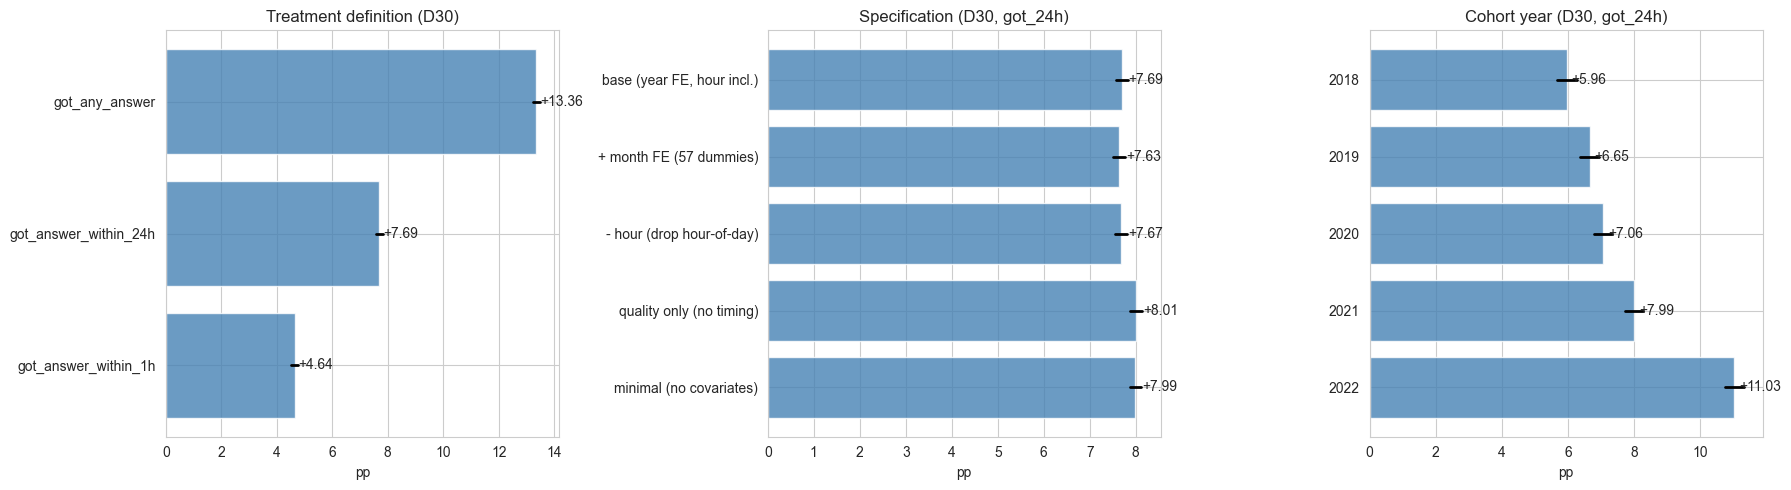

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
y = np.arange(len(treatments_table))
ax.barh(y, treatments_table['controlled_pp'], color='steelblue', alpha=0.8)
for i, row in treatments_table.iterrows():
    ax.plot([row['ci_low'], row['ci_high']], [i, i], 'k-', lw=2)
    ax.text(row['controlled_pp'] + 0.15, i, f"{row['controlled_pp']:+.2f}", va='center', fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(treatments_table['treatment'])
ax.axvline(0, color='black', lw=0.5)
ax.set_title('Treatment definition (D30)'); ax.set_xlabel('pp')
ax.invert_yaxis()

ax = axes[1]
y = np.arange(len(specs_table))
ax.barh(y, specs_table['estimate_pp'], color='steelblue', alpha=0.8)
for i, row in specs_table.iterrows():
    ax.plot([row['ci_low'], row['ci_high']], [i, i], 'k-', lw=2)
    ax.text(row['estimate_pp'] + 0.15, i, f"{row['estimate_pp']:+.2f}", va='center', fontsize=10)
ax.set_yticks(y); ax.set_yticklabels(specs_table['spec'])
ax.axvline(0, color='black', lw=0.5)
ax.set_title('Specification (D30, got_24h)'); ax.set_xlabel('pp')
ax.invert_yaxis()

ax = axes[2]
y = np.arange(len(years_table))
ax.barh(y, years_table['controlled_pp'], color='steelblue', alpha=0.8)
for i, row in years_table.iterrows():
    ax.plot([row['ci_low'], row['ci_high']], [i, i], 'k-', lw=2)
    ax.text(row['controlled_pp'] + 0.15, i, f"{row['controlled_pp']:+.2f}", va='center', fontsize=10)
ax.set_yticks(y); ax.set_yticklabels([str(int(y)) for y in years_table['cohort_year']])
ax.axvline(0, color='black', lw=0.5)
ax.set_title('Cohort year (D30, got_24h)'); ax.set_xlabel('pp')
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 4. Save and summarize

Saving all three tables to one parquet for the dashboard.

In [6]:
treatments_table['kind'] = 'treatment'
specs_table['kind'] = 'specification'; specs_table = specs_table.rename(columns={'spec': 'label', 'estimate_pp': 'controlled_pp'})
years_table['kind'] = 'subsample'; years_table = years_table.rename(columns={'cohort_year': 'label'}); years_table['label'] = years_table['label'].astype(str)
treatments_table = treatments_table.rename(columns={'treatment': 'label'})

all_robust = pd.concat([
    treatments_table[['kind', 'label', 'controlled_pp', 'se_pp', 'ci_low', 'ci_high']],
    specs_table[['kind', 'label', 'controlled_pp', 'se_pp', 'ci_low', 'ci_high']],
    years_table[['kind', 'label', 'controlled_pp', 'se_pp', 'ci_low', 'ci_high']],
], ignore_index=True)

out_path = f'{DATA_DIR}/robustness.parquet'
all_robust.to_parquet(out_path, index=False)
print(f'Saved: {out_path}')
print()
print(all_robust.to_string(index=False, float_format=lambda x: f'{x:+.2f}' if isinstance(x, float) else str(x)))

Saved: ../data/processed/robustness.parquet

         kind                      label  controlled_pp  se_pp  ci_low  ci_high
    treatment             got_any_answer         +13.36  +0.07  +13.23   +13.49
    treatment      got_answer_within_24h          +7.69  +0.07   +7.56    +7.82
    treatment       got_answer_within_1h          +4.64  +0.07   +4.51    +4.77
specification base (year FE, hour incl.)          +7.69  +0.07   +7.56    +7.82
specification    + month FE (57 dummies)          +7.63  +0.07   +7.50    +7.76
specification  - hour (drop hour-of-day)          +7.67  +0.07   +7.55    +7.80
specification   quality only (no timing)          +8.01  +0.06   +7.88    +8.13
specification    minimal (no covariates)          +7.99  +0.06   +7.87    +8.12
    subsample                       2018          +5.96  +0.15   +5.66    +6.26
    subsample                       2019          +6.65  +0.15   +6.36    +6.95
    subsample                       2020          +7.06  +0.14   +6.78    +